*Cinemática de un Proyectil con Tracker y Cálculo Numérico*

Diferenciación Numerica

In [7]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import argparse

Función read_data para leer los valores de el archivo .txt y carga su contenido a una tabla de pandas, de tal forma que los espacios los interpreta como separadores de columna

In [1]:
def read_data(file_name:str):
    points = pd.read_csv(f"data/{file_name}", sep='\\s+')
    return points 

Funciones para los diferentes tipos de derivada (backward. forward, central, richardson), las cuales actuan en los elementos ii-ésimos iterando segun convenga en cada tipo de derivada.

In [8]:
def backward(x:np.array, t:np.array, ii):
    h = t[ii] - t[ii-1] #Careful with ii
    return (x[ii]-(x[ii-1]))/h
    
def forward(x:np.array, t:np.array, ii):
    h = t[ii+1] - t[ii] #Careful with ii
    return ((x[ii+1])-x[ii])/h

def central(x:np.array, t:np.array, ii:int, h_factor=1):
    h = (t[ii] - t[ii-1])/h_factor #Careful with ii
    return ((x[ii+1])-x[ii-1])/(2*h)

def richardson(x:np.array, t:np.array, ii:int):
    return (central(x,t,ii,2))+(1/3)*(central(x,t,ii,2)-central(x,t,ii))

Función stimate_gravity_central para estimar la aceleración gravitacional usando los datos obtenidos.

In [25]:
def stimate_gravity(method_name: str, acceleration: np.array, g_theoretical=9.81):
    
    flight_a_y = np.array(acceleration)[2:-2]
    g_exp = np.abs(np.mean(flight_a_y))
    
    err_pct = relative_error(g_theoretical, g_exp) * 100
    
    print("\n" + "="*50)
    print(f" Gravity stimation ({method_name}) ")
    print("="*50)
    print(f"Experimental g : {g_exp:.4f} m/s²")
    print(f"Relative error : {err_pct:.2f}%")
    print("="*50 + "\n")
    
    return g_exp

Fuciones para el calculo de los erroes relativo y porcentuales

In [21]:
def absolute_error(true, experimental):
    return np.abs(np.array(true) - np.array(experimental))

def relative_error(true, experimental):
    true_arr = np.array(true)
    exp_arr = np.array(experimental)
    denominador = np.maximum(np.abs(true_arr), 1e-2)
    return absolute_error(true_arr, exp_arr) / denominador

Funciones para integración 

In [26]:
def trapezoid_step(time: np.array, velocity: np.array, ii: int):
    h = time[ii] - time[ii-1]
    integral = (h/2) * (velocity[ii-1] + velocity[ii])
    return integral

def reconstruct_trapezoid(time: np.array, velocity: np.array, initial_position: float):
    position = [initial_position]
    for ii in range(1, len(time)):
        integral = trapezoid_step(time, velocity, ii)
        position.append(position[ii-1] + integral)
    return position

def simpson_13_step(time: np.array, velocity: np.array, ii: int):
    h1 = time[ii-1] - time[ii-2]
    h2 = time[ii] - time[ii-1]
    if not np.isclose(h1, h2):
        return None
    h = h1
    integral = (h/3) * (velocity[ii-2] + 4*velocity[ii-1] + velocity[ii])
    return integral

def reconstruct_simpson(time: np.ndarray, velocity: np.ndarray, initial_position: float) -> list:
    position = [initial_position]
    for ii in range(1, len(time)):
        if ii % 2 == 0:
            integral = simpson_13_step(time, velocity, ii)
            if integral is not None:
                position.append(position[ii-2] + integral)
            else:
                position.append(position[ii-1] + trapezoid_step(time, velocity, ii))
        else:
            position.append(position[ii-1] + trapezoid_step(time, velocity, ii))
    return position

Funciones para gráficar X vs t, Y vs t, Y vs X

In [27]:
def position_plot(time, x_pos, y_pos, x_real=None, y_real=None, method_name=None, folder_name='results'):
    os.makedirs(folder_name, exist_ok=True) # Create the folder if it doesn't exist

    has_real = (x_real is not None) and (y_real is not None) and (method_name is not None)
    fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(15, 4.5))

    label_x = f'Reconstructed {method_name}' if has_real else 'x(t)'
    ax1.plot(time, x_pos, color='tab:blue', linewidth=2, label=label_x)
    if has_real:
        ax1.plot(time, x_real, color='black', linestyle='--', linewidth=1.5, label='Real')
        ax1.legend()
    ax1.set_title('Position X vs Time')
    ax1.set_xlabel('Time (t)')
    ax1.set_ylabel('Position X')
    ax1.grid(True)

    label_y = f'Reconstructed {method_name}' if has_real else 'y(t)'
    ax2.plot(time, y_pos, color='tab:orange', linewidth=2, label=label_y)
    if has_real:
        ax2.plot(time, y_real, color='black', linestyle='--', linewidth=1.5, label='Real')
        ax2.legend()
    ax2.set_title('Position Y vs Time')
    ax2.set_xlabel('Time (t)')
    ax2.set_ylabel('Position Y')
    ax2.grid(True)

    label_xy = f'Reconstructed {method_name}' if has_real else 'y(x)'
    ax3.plot(x_pos, y_pos, color='tab:green', linewidth=2, label=label_xy)
    if has_real:
        ax3.plot(x_real, y_real, color='black', linestyle='--', linewidth=1.5, label='Real')
        ax3.legend()
    ax3.set_title('Position Y vs Position X')
    ax3.set_xlabel('Position X')
    ax3.set_ylabel('Position Y')
    ax3.grid(True)

    plt.tight_layout()
    file_path = os.path.join(folder_name, "positions.pdf")
    plt.savefig(file_path, dpi=300, bbox_inches='tight') # Save the plot as a PDF file
    plt.show()
    plt.close(fig) # Close the plot to free memory

Función grouped_plot gráfica y compara distintos datos, por ejemplo: gráfica las velocidades exportadas de tracker y las velocidades calculadas con las funciones de diferenciación y las compara lado a lado

In [4]:
def grouped_plot(mode, time, arrays_x, arrays_y, labels, folder_name='results'):
    os.makedirs(folder_name, exist_ok=True)
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 4.5))

    plots_config = [
        (ax1, arrays_x, "x"),
        (ax2, arrays_y, "y")]

    for ax, array_data, axis in plots_config:
        for ii, name in enumerate(labels):
            if ii == 0:
                lbl = f'Tracker {mode}_{axis}(t)'
            else:
                lbl = f'{mode}_{axis}_{name}'
            
            ax.plot(time, array_data[ii], label=lbl)

        ax.set_title(f'{mode.upper()} {axis.upper()}', fontweight='bold')
        ax.set_xlabel('Time')
        ax.set_ylabel(f'{axis.upper()} component')
        ax.grid(True)
        ax.legend() 

    plt.tight_layout()

    file_path = os.path.join(folder_name, f"{mode}.pdf")
    plt.savefig(file_path, dpi=300, bbox_inches='tight')
    plt.show()
    plt.close(fig)

Función rel_error_plot gráfica el error relativo de las componentes vectoriales de la velocidad y la aceleración

In [5]:
def rel_error_plot(time, arrays, titles, labels, folder_name='results'):
    fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharex=True)

    for ii, ax in enumerate(axes.flat):
        current_group = arrays[ii]
        
        for jj, plot in enumerate(current_group):
            if ii == 0:
                kk = jj
            else:
                kk = jj +4
            ax.plot(time, plot, label=labels[jj], linewidth=1.5)

        ax.set_title(titles[ii], fontsize=10, fontweight='bold')
        ax.set_ylabel('Relative error', fontsize=9)
        ax.grid(True)
        ax.legend(fontsize=8, loc='best')
        
        if ii >= 2:
            ax.set_xlabel('Time (t)', fontsize=9)

    plt.tight_layout()

    file_path = os.path.join(folder_name, f"relative_error.pdf")
    plt.savefig(file_path, dpi=300, bbox_inches='tight')
    plt.show()
    plt.close(fig)


Función main ejecuta la diferenciación cuidando que para Forward en (ii=0) ya que no existen puntos anteriores, en el ultimo punto solo se usa Backward ya que no existen puntos posteriores y en los puntos intermedios si se aplican los cuatro métodos


 Gravity stimation (<function central at 0x7473ff30fce0>) 
Experimental g : 10.6528 m/s²
Relative error : 8.59%



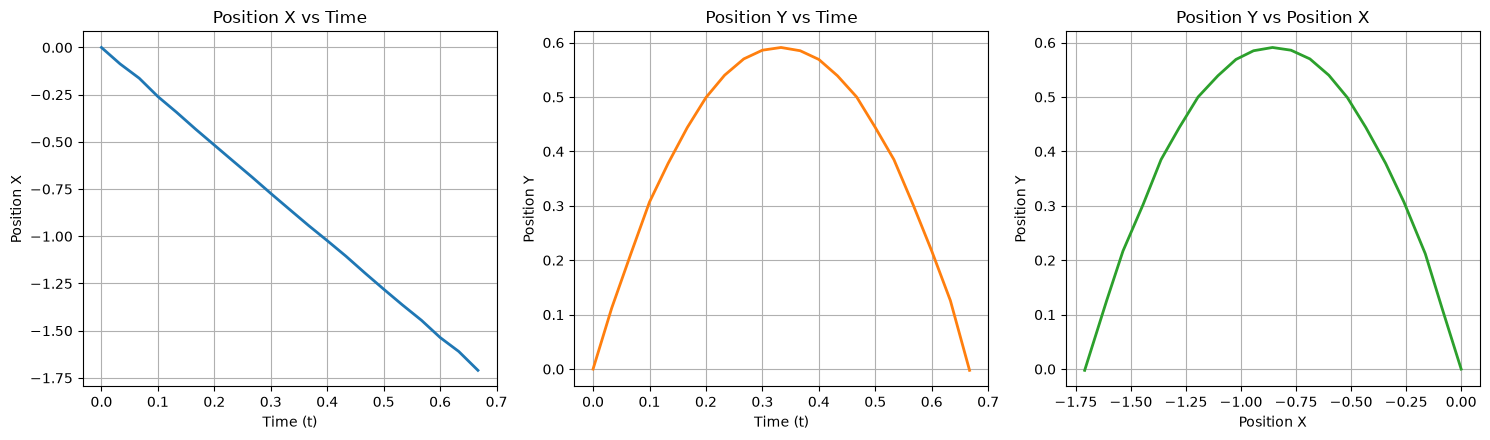

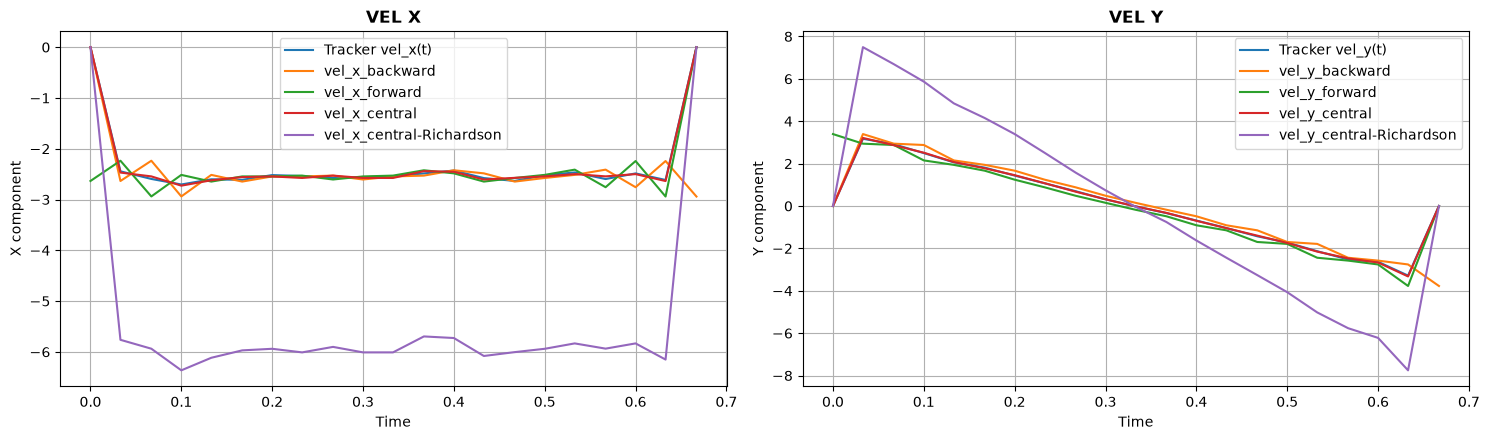

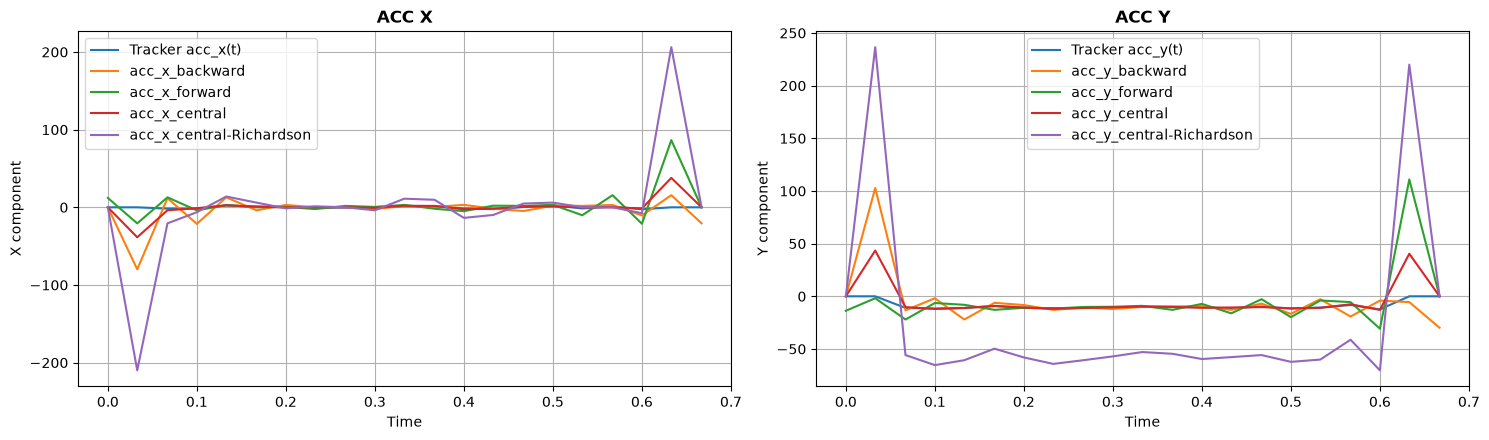

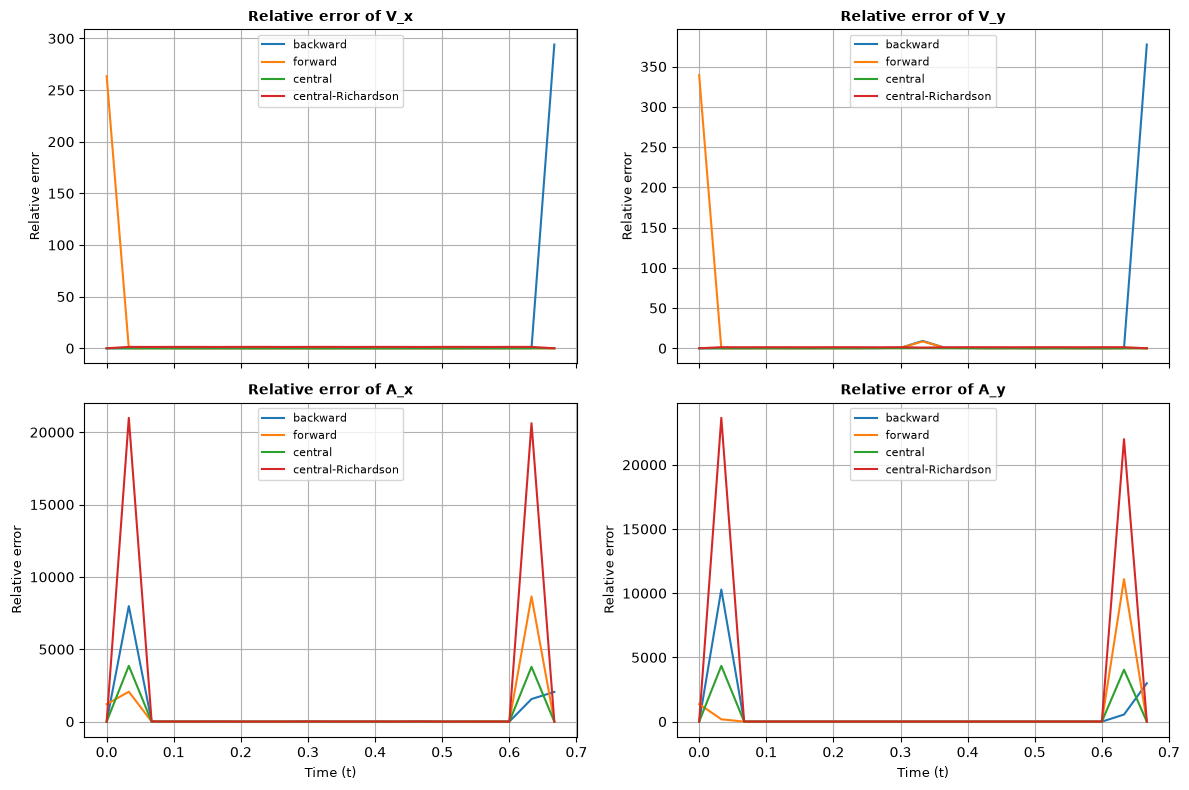

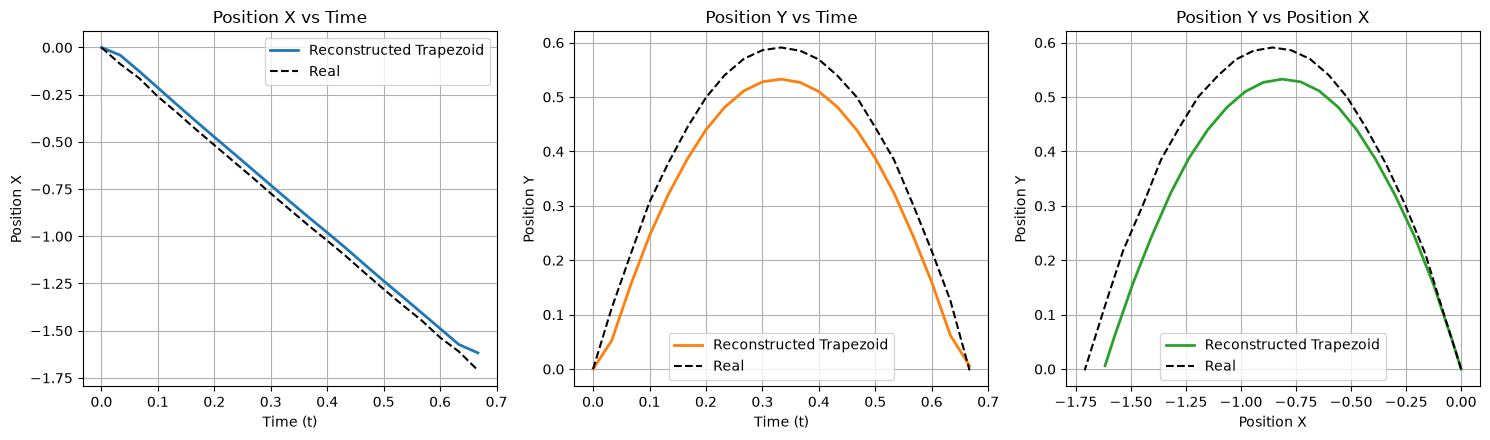

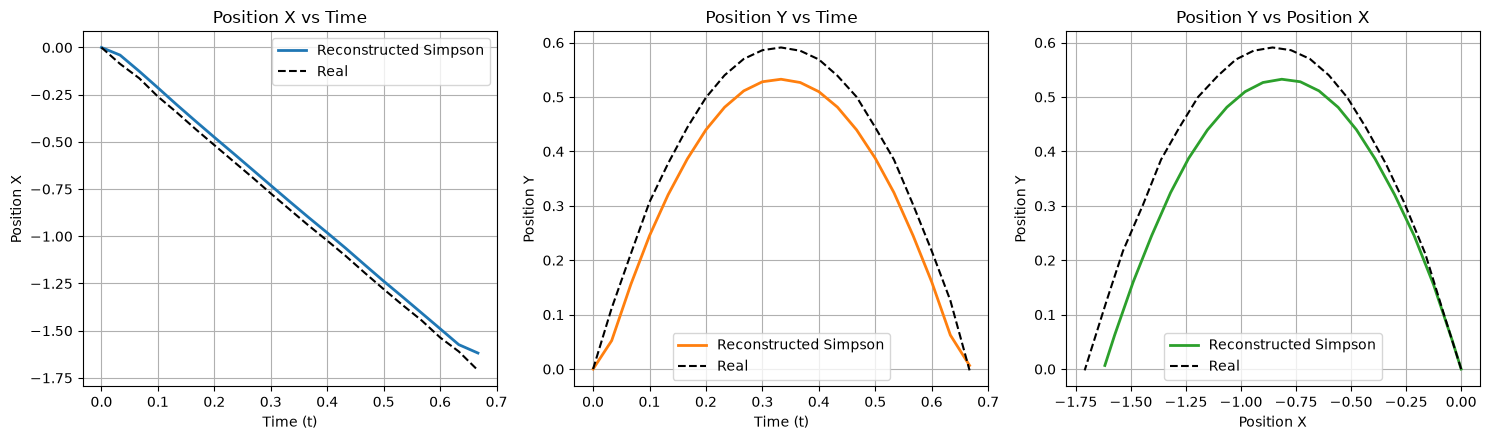

In [32]:
def main():
    
    data = read_data("raw_data.txt")
    #print(data.head())
    #print(len(data["t"]))

    v_x_bw = []
    v_x_fw = []
    v_x_cn = []
    v_x_rc = []

    v_y_bw = []
    v_y_fw = []
    v_y_cn = []
    v_y_rc = []    

    a_x_bw = []
    a_x_fw = []
    a_x_cn = []
    a_x_rc = []

    a_y_bw = []
    a_y_fw = []
    a_y_cn = []
    a_y_rc = []

    #Velocity
    for ii in range(0, len(data["t"])):
        if ii == 0:
            v_x_bw.append(0)
            v_y_bw.append(0)
            v_x_fw.append(forward(data["x"], data["t"], ii))
            v_y_fw.append(forward(data["y"], data["t"], ii))
            v_x_cn.append(0)
            v_y_cn.append(0)
            v_x_rc.append(0)
            v_y_rc.append(0)
        elif ii != 0 and ii != len(data["t"])-1:
            v_x_bw.append(backward(data["x"], data["t"], ii))
            v_y_bw.append(backward(data["y"], data["t"], ii))
            v_x_fw.append(forward(data["x"], data["t"], ii))
            v_y_fw.append(forward(data["y"], data["t"], ii))
            v_x_cn.append(central(data["x"], data["t"], ii))
            v_y_cn.append(central(data["y"], data["t"], ii))
            v_x_rc.append(richardson(data["x"], data["t"], ii))
            v_y_rc.append(richardson(data["y"], data["t"], ii))
        elif ii == len(data["t"])-1:
            v_x_bw.append(backward(data["x"], data["t"], ii))
            v_y_bw.append(backward(data["y"], data["t"], ii))
            v_x_fw.append(0)
            v_y_fw.append(0)
            v_x_cn.append(0)
            v_y_cn.append(0)
            v_x_rc.append(0)
            v_y_rc.append(0)
    
    rel_error_v_x_bw = relative_error(data["vx"], v_x_bw)
    rel_error_v_y_bw = relative_error(data["vy"], v_y_bw)
    rel_error_v_x_fw = relative_error(data["vx"], v_x_fw)
    rel_error_v_y_fw = relative_error(data["vy"], v_y_fw)
    rel_error_v_x_cn = relative_error(data["vx"], v_x_cn)
    rel_error_v_y_cn = relative_error(data["vy"], v_y_cn)
    rel_error_v_x_rc = relative_error(data["vx"], v_x_rc)
    rel_error_v_y_rc = relative_error(data["vy"], v_y_rc)

    rel_error_V_x = [rel_error_v_x_bw, rel_error_v_x_fw, rel_error_v_x_cn, rel_error_v_x_rc]
    rel_error_V_y = [rel_error_v_y_bw, rel_error_v_y_fw, rel_error_v_y_cn, rel_error_v_y_rc]
    #print(rel_error_V_x)
    #print(rel_error_V_y)
    

    #Acceleration
    for ii in range(0, len(data["t"])):
        if ii == 0:
            a_x_bw.append(0)
            a_y_bw.append(0)
            a_x_fw.append(forward(v_x_fw, data["t"], ii))
            a_y_fw.append(forward(v_y_fw, data["t"], ii))
            a_x_cn.append(0)
            a_y_cn.append(0)
            a_x_rc.append(0)
            a_y_rc.append(0)
        elif ii != 0 and ii != len(data["t"])-1:
            a_x_bw.append(backward(v_x_bw, data["t"], ii))
            a_y_bw.append(backward(v_y_bw, data["t"], ii))
            a_x_fw.append(forward(v_x_fw, data["t"], ii))
            a_y_fw.append(forward(v_y_fw, data["t"], ii))
            a_x_cn.append(central(v_x_cn, data["t"], ii))
            a_y_cn.append(central(v_y_cn, data["t"], ii))
            a_x_rc.append(richardson(v_x_rc, data["t"], ii))
            a_y_rc.append(richardson(v_y_rc, data["t"], ii))
        elif ii == len(data["t"])-1:
            a_x_bw.append(backward(v_x_bw, data["t"], ii))
            a_y_bw.append(backward(v_y_bw, data["t"], ii))
            a_x_fw.append(0)
            a_y_fw.append(0)
            a_x_cn.append(0)
            a_y_cn.append(0)
            a_x_rc.append(0)
            a_y_rc.append(0)



    rel_error_a_x_bw = relative_error(data["ax"], a_x_bw)
    rel_error_a_y_bw = relative_error(data["ay"], a_y_bw)
    rel_error_a_x_fw = relative_error(data["ax"], a_x_fw)
    rel_error_a_y_fw = relative_error(data["ay"], a_y_fw)
    rel_error_a_x_cn = relative_error(data["ax"], a_x_cn)
    rel_error_a_y_cn = relative_error(data["ay"], a_y_cn)
    rel_error_a_x_rc = relative_error(data["ax"], a_x_rc)
    rel_error_a_y_rc = relative_error(data["ay"], a_y_rc)

    rel_error_A_x = [rel_error_a_x_bw, rel_error_a_x_fw, rel_error_a_x_cn, rel_error_a_x_rc]
    rel_error_A_y = [rel_error_a_y_bw, rel_error_a_y_fw, rel_error_a_y_cn, rel_error_a_y_rc]
    #print(rel_error_A_x)
    #print(rel_error_A_y)
  
    g_exp = stimate_gravity(central, a_y_cn)

    position_plot(data["t"], data["x"], data["y"])

    lables = [None, "backward", "forward", "central", "central-Richardson"]
    vel_x = [data["vx"], v_x_bw, v_x_fw, v_x_cn, v_x_rc]
    vel_y = [data["vy"], v_y_bw, v_y_fw, v_y_cn, v_y_rc]
    grouped_plot("vel", data["t"], vel_x, vel_y, lables)

    acc_x = [data["ax"], a_x_bw, a_x_fw, a_x_cn, a_x_rc]
    acc_y = [data["ay"], a_y_bw, a_y_fw, a_y_cn, a_y_rc]
    grouped_plot("acc", data["t"], acc_x, acc_y, lables)

    rel_titles = ["Relative error of V_x", "Relative error of V_y", "Relative error of A_x", "Relative error of A_y"]
    rel_lables = ["backward", "forward", "central", "central-Richardson"]
    rel_errors = [rel_error_V_x, rel_error_V_y, rel_error_A_x, rel_error_A_y]
    rel_error_plot(data["t"], rel_errors, rel_titles, rel_lables)

    fout = open("results/results.txt", "w") # Open a file to write the results
    fout.write(f"--- Mean relative error ---\n")
    fout.write(f"(Velocity-X backward)={np.mean(rel_error_v_x_bw[1:-1]):.4f}\n")
    fout.write(f"(Velocity-X forward)={np.mean(rel_error_v_x_fw[1:-1]):.4f}\n")
    fout.write(f"(Velocity-X central)={np.mean(rel_error_v_x_cn[1:-1]):.4f}\n")
    fout.write(f"(Velocity-X central-Richardson)={np.mean(rel_error_v_x_rc[1:-1]):.4f}\n")
    fout.write("#"*30)
    fout.write("\n")
    fout.write(f"(Acceleration-X backward)={np.mean(rel_error_a_x_bw[2:-2]):.4f}\n")
    fout.write(f"(Acceleration-X forward)={np.mean(rel_error_a_x_fw[2:-2]):.4f}\n")
    fout.write(f"(Acceleration-X central)={np.mean(rel_error_a_x_cn[2:-2]):.4f}\n")
    fout.write(f"(Acceleration-X central-Richardson)={np.mean(rel_error_a_x_rc[2:-2]):.4f}\n")

    #Integration: position reconstruction
    x0 = data["x"].iloc[0]
    y0 = data["y"].iloc[0]

    x_trap = reconstruct_trapezoid(data["t"], data["vx"], x0)
    y_trap = reconstruct_trapezoid(data["t"], data["vy"], y0)
    x_simp = reconstruct_simpson(data["t"], data["vx"], x0)
    y_simp = reconstruct_simpson(data["t"], data["vy"], y0)

    abs_error_x_trap = absolute_error(np.array(data["x"]), np.array(x_trap))
    abs_error_y_trap = absolute_error(np.array(data["y"]), np.array(y_trap))
    abs_error_x_simp = absolute_error(np.array(data["x"]), np.array(x_simp))
    abs_error_y_simp = absolute_error(np.array(data["y"]), np.array(y_simp))

    rel_error_x_trap = relative_error(np.array(data["x"]), np.array(x_trap))
    rel_error_y_trap = relative_error(np.array(data["y"]), np.array(y_trap))
    rel_error_x_simp = relative_error(np.array(data["x"]), np.array(x_simp))
    rel_error_y_simp = relative_error(np.array(data["y"]), np.array(y_simp))

    position_plot(data["t"], x_trap, y_trap, x_real=data["x"], y_real=data["y"], method_name="Trapezoid")
    position_plot(data["t"], x_simp, y_simp, x_real=data["x"], y_real=data["y"], method_name="Simpson")

    fout.write(f"\n--- Mean relative error of position reconstruction ---\n")
    fout.write(f"(Position-X Trapezoid)={np.mean(rel_error_x_trap[1:-1]):.4f}\n")
    fout.write(f"(Position-Y Trapezoid)={np.mean(rel_error_y_trap[1:-1]):.4f}\n")
    fout.write(f"(Position-X Simpson)={np.mean(rel_error_x_simp[1:-1]):.4f}\n")
    fout.write(f"(Position-Y Simpson)={np.mean(rel_error_y_simp[1:-1]):.4f}\n")

    fout.close() # Close the file after writing the results
if __name__ == "__main__":
    main()

*Preguntas de Discusión en el Informe*

1. ¿Por qué la gráfica de aceleración obtenida mediante diferenciación numérica se ve mucho más ruidosa e irregular que la gráfica de posición original? Expliquen el fenómeno de amplificación de ruido en la derivada numérica.

Rta/ 

La gráfica de la trayectoria (x,y) se ve suave porque Tracker rastrea el ping pong cuadro a cuadro, el video se grabo a 30 fps lo que significa que el salto de un fps a otro toma unos 0.033 segundos, por otro lado la posición tiene un error de 0.001m, el ping pong recorrio poco mas de 0.6m, así que un error de 0.001m es practicamente imperceptible, por otro lado al momento de calcular las derivadas se toma la posición que a grandes rasgos es x_exp = x_real(t) + error(0.001m) y se dividen entre 0.033s, así que para la velocidad el error es de 0.001m/0.033s = 0.03030m/s, es decir 30 veces el error de la posición, bajo el mismo razonamiento, pero recordando que para la aceleración se esta haciendo la segunda derivada el error de la aceleración es 0.001m/(0
033s)^2 = 0.918m/s^2, es decir unas 900 veces el error de la posición, esto ocurre porque cada vez que se deriva se divide por un valor cada cez más pequeño, lo que hace que el error se acumule. Cabe aclara que el error tambien depende del método utilizado para la derivada.

2. ¿Qué ocurre en los extremos del intervalo temporal t(0) y t(final) con los esquemas centrales y cómo los manejaron en su código?

Rta/

En los esquemas centrales de diferenciación finita, los extremos t(0) y t(final) no se pueden calcular directamente porque la fórmula requiere de un punto anterior t_(ii-1) y uno posterior t_(ii+1), los cuales no existen fuera del intervalo del experimento.En el código de Python, este problema se manejó asignando valores nulos/descentrados en los extremos para mantener la dimensión de los arreglos sin romper la ejecución. Posteriormente, al momento de graficar y calcular el error relativo promedio, se descartaron estos puntos de frontera mediante recorte de vectores ([1:-1] en velocidad y [2:-2] en aceleración), asegurando que los elementos de borde no distorsionaran el análisis del comportamiento físico.

3. ¿Cuál de los métodos de integración (Trapecio vs. Simpson) acumuló menor error respecto a la posición real? ¿La integración suavizó o empeoró el ruido de la velocidad?

Rta/

El menor error fue optenido por el método de Simpson, la integración suavizó el ruido de la velocidad por ambos métodos

4. ¿Por qué la integración numérica actúa como un filtro suavizador, mientras que la diferenciación numérica actúa como un amplificador de ruido?

Rta/

La integración númerica es a grandes rasgos una sumatoria, los datos tienen un error que varia entre (error, -error) al sumarlos estos errores positivos y negativos se cancelan lo que "suaviza" la curva, por otro lado como se explico en el iteral 1. el algoritmo de diferenciación amplifica el error.


5. Si compara con los datos de v y a en cada dimensión que obtiene por tracker, observa el mismo ruido? qué algoritmo puede estar usando tracker?


Rta/ 

Debe ser una algoritmo optimizado central, ya que los valores iniciales y finales no se reportan.